In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np

In [ ]:
df=pd.read_csv("/content/Employee.csv")
df

,Company,Age,Salary,Place,Country,Gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


DATA EXPLORATION

1. Explore the data, list down the unique values in each feature and find its length.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Company  140 non-null    object 
 1   Age      130 non-null    float64
 2   Salary   124 non-null    float64
 3   Place    134 non-null    object 
 4   Country  148 non-null    object 
 5   Gender   148 non-null    int64  
dtypes: float64(2), int64(1), object(3)
memory usage: 7.1+ KB


In [ ]:
df.shape

(148, 6)

In [ ]:
df.size

888

In [ ]:
for col in df.columns:
    print(col)
    print(df[col].unique())
    print("Length =", len(df[col].unique()))

Company
['TCS' 'Infosys' 'CTS' nan 'Tata Consultancy Services' 'Congnizant'
 'Infosys Pvt Lmt']
Length = 7
Age
[20. 30. 35. 40. 23. nan 34. 45. 18. 22. 32. 37. 50. 21. 46. 36. 26. 41.
 24. 25. 43. 19. 38. 51. 31. 44. 33. 17.  0. 54.]
Length = 30
Salary
[  nan 2300. 3000. 4000. 5000. 6000. 7000. 8000. 9000. 1089. 1234. 3030.
 3045. 3184. 4824. 5835. 7084. 8943. 8345. 9284. 9876. 2034. 7654. 2934.
 4034. 5034. 8202. 9024. 4345. 6544. 6543. 3234. 4324. 5435. 5555. 8787.
 3454. 5654. 5009. 5098. 3033.]
Length = 41
Place
['Chennai' 'Mumbai' 'Calcutta' 'Delhi' 'Podicherry' 'Cochin' nan 'Noida'
 'Hyderabad' 'Bhopal' 'Nagpur' 'Pune']
Length = 12
Country
['India']
Length = 1
Gender
[0 1]
Length = 2


2. Perform the statistical analysis and renaming of the columns.

In [ ]:
df.describe()

,Age,Salary,Gender
count,130.000000,124.000000,148.000000
mean,30.484615,5312.467742,0.222973
std,11.096640,2573.764683,0.417654
min,0.000000,1089.000000,0.000000
25%,22.000000,3030.000000,0.000000
50%,32.500000,5000.000000,0.000000
75%,37.750000,8000.000000,0.000000
max,54.000000,9876.000000,1.000000


In [ ]:
df.rename(columns={"Company":"company","Age":"age","Salary":"salary","Place":"place","Country":"country","Gender":"gender"},
          inplace=True)

In [ ]:
df

,company,age,salary,place,country,gender
0,TCS,20.0,NaN,Chennai,India,0
1,Infosys,30.0,NaN,Mumbai,India,0
2,TCS,35.0,2300.0,Calcutta,India,0
3,Infosys,40.0,3000.0,Delhi,India,0
4,TCS,23.0,4000.0,Mumbai,India,0
...,...,...,...,...,...,...
143,TCS,33.0,9024.0,Calcutta,India,1
144,Infosys,22.0,8787.0,Calcutta,India,1
145,Infosys,44.0,4034.0,Delhi,India,1
146,TCS,33.0,5034.0,Mumbai,India,1


DATA CLEANING

1. Find the missing and inappropriate values, treat them appropriately.

In [ ]:
df.isnull().sum()

,0
company,8
age,18
salary,24
place,14
country,0
gender,0


In [ ]:
df["company"]=df["company"].replace({
    "Tata Consultancy Services":"TCS",
    "Congnizant":"CTS",
    "Infosys Pvt Lmt":"Infosys"})


In [ ]:
df["company"].head(25)

,company
0,TCS
1,Infosys
2,TCS
3,Infosys
4,TCS
5,Infosys
6,TCS
7,Infosys
8,TCS
9,CTS


2. Remove all duplicate rows.

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(144, 6)

3. Find the outliers.

<Axes: >

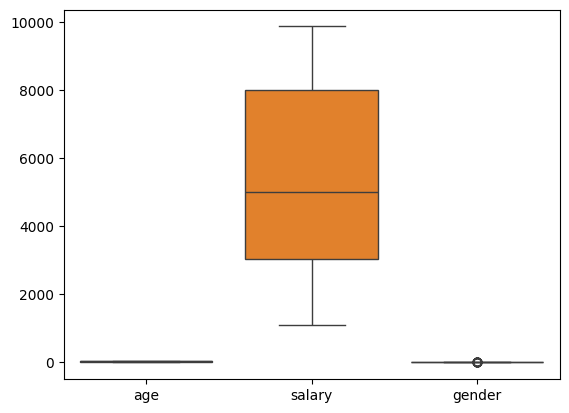

In [ ]:
sns.boxplot(df)

<Axes: ylabel='age'>

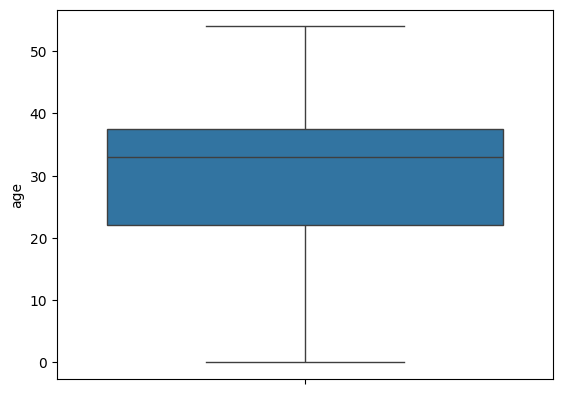

In [ ]:
sns.boxplot(df["age"])

<Axes: ylabel='salary'>

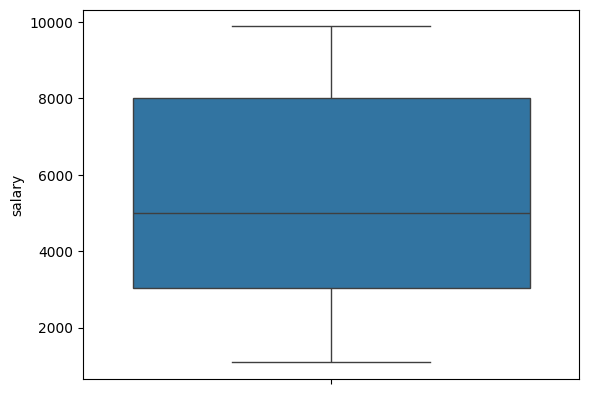

In [ ]:
sns.boxplot(df["salary"])

4. Replace the value 0 in age as NaN Treat the null values in all columns using any
measures(removing/ replace the values with mean/median/mode)

In [ ]:
df.isnull().sum()

,0
company,8
age,17
salary,23
place,14
country,0
gender,0


In [ ]:
df["age"]=df["age"].replace(0,np.nan)

In [ ]:
df["age"]=df["age"].fillna(df["age"].median())

In [ ]:
df["salary"]=df["salary"].fillna(df["salary"].median())

In [ ]:
df["company"]=df["company"].fillna(df["company"].mode()[0])

In [ ]:
df["place"]=df["place"].fillna(df["place"].mode()[0])

In [ ]:
df.isnull().sum()

,0
company,0
age,0
salary,0
place,0
country,0
gender,0


DATA ANALYSIS

1. Filter the data with age >40 and salary<5000 Plot the chart with age and salary Count the number of people from each place and represent it visually

In [ ]:
filter1=df[(df["age"]>40) & (df["salary"]<5000)]

In [ ]:
filter1.reset_index(inplace=True)

In [ ]:
filter1

,index,company,age,salary,place,country,gender
0,21,Infosys,50.0,3184.0,Delhi,India,0
1,32,Infosys,45.0,4034.0,Calcutta,India,0
2,39,Infosys,41.0,3000.0,Mumbai,India,0
3,50,Infosys,41.0,3000.0,Chennai,India,0
4,57,Infosys,51.0,3184.0,Hyderabad,India,0
5,68,Infosys,43.0,4034.0,Mumbai,India,0
6,75,Infosys,44.0,3000.0,Cochin,India,0
7,86,Infosys,41.0,3000.0,Delhi,India,0
8,93,Infosys,54.0,3184.0,Mumbai,India,0
9,104,Infosys,44.0,4034.0,Delhi,India,0


In [ ]:
import matplotlib.pyplot as plt

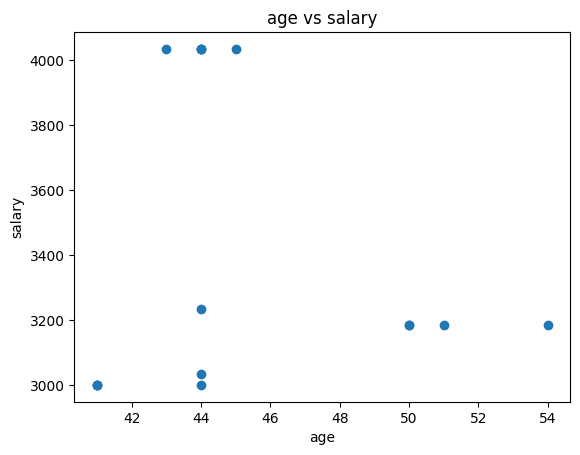

In [ ]:
plt.scatter(filter1["age"],filter1["salary"])
plt.xlabel("age")
plt.ylabel("salary")
plt.title("age vs salary")
plt.show()

In [ ]:
df["place"].value_counts()

,count
place,
Mumbai,48
Calcutta,32
Chennai,14
Delhi,14
Cochin,13
Noida,8
Hyderabad,8
Podicherry,3
Pune,2


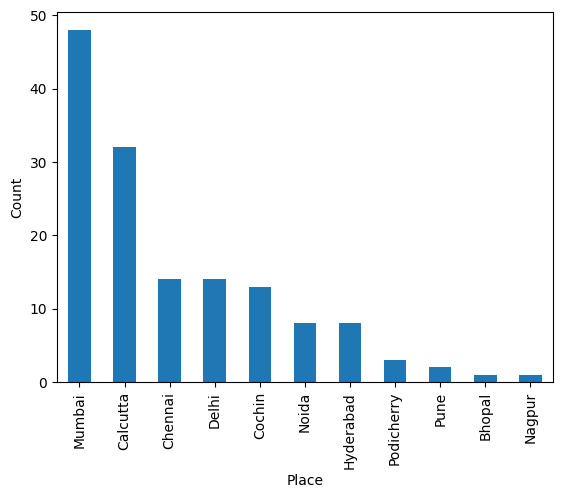

In [ ]:
df["place"].value_counts().plot(kind="bar")
plt.xlabel("Place")
plt.ylabel("Count")
plt.show()

DATA ENCODING

Convert categorical variables into numerical representations using techniques such as one-hot encoding, label encoding, making them suitable for analysis by machine learning algorithms.

In [ ]:
df.dtypes

,0
company,object
age,float64
salary,float64
place,object
country,object
gender,int64


one-hot encoding

In [ ]:
pd.get_dummies(df,columns=["company","place","country"], dtype=int)

,age,salary,gender,company_CTS,company_Infosys,company_TCS,place_Bhopal,place_Calcutta,place_Chennai,place_Cochin,place_Delhi,place_Hyderabad,place_Mumbai,place_Nagpur,place_Noida,place_Podicherry,place_Pune,country_India
0,20.0,5000.0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1
1,30.0,5000.0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
2,35.0,2300.0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1
3,40.0,3000.0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
4,23.0,4000.0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
142,22.0,8202.0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,1
143,33.0,9024.0,1,0,0,1,0,1,0,0,0,0,0,0,0,0,0,1
145,44.0,4034.0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1
146,33.0,5034.0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1


label encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df["company"]=le.fit_transform(df["company"])
df["place"]=le.fit_transform(df["place"])
df["country"]=le.fit_transform(df["country"])

In [ ]:
df.dtypes

,0
company,int64
age,float64
salary,float64
place,int64
country,int64
gender,int64


FEATURE SCALING

1.After the process of encoding, perform the scaling of the features using
standardscaler and minmaxscaler.

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
scaled=ss.fit_transform(df[["age","company"]])
scaled

array([[-1.48467637,  1.01925559],
       [-0.26717411, -0.21412933],
       [ 0.34157702,  1.01925559],
       [ 0.95032816, -0.21412933],
       [-1.11942569,  1.01925559],
       [ 0.09807657, -0.21412933],
       [ 0.09807657,  1.01925559],
       [-1.11942569, -0.21412933],
       [ 0.2198268 ,  1.01925559],
       [ 1.55907929, -1.44751424],
       [-1.11942569, -1.44751424],
       [ 0.2198268 , -1.44751424],
       [ 1.55907929, -1.44751424],
       [-1.72817683, -1.44751424],
       [ 0.95032816, -0.21412933],
       [-1.11942569,  1.01925559],
       [-1.11942569, -0.21412933],
       [ 0.2198268 ,  1.01925559],
       [-1.24117592,  1.01925559],
       [-0.02367366, -0.21412933],
       [ 0.58507748,  1.01925559],
       [ 2.16783042, -0.21412933],
       [-1.36292615,  1.01925559],
       [ 0.09807657, -0.21412933],
       [ 0.09807657,  1.01925559],
       [-1.11942569, -0.21412933],
       [ 0.2198268 ,  1.01925559],
       [ 1.55907929, -1.44751424],
       [-1.11942569,

In [ ]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
scaled=minmax.fit_transform(df[["age","salary"]])
scaled

array([[0.08108108, 0.44508934],
       [0.35135135, 0.44508934],
       [0.48648649, 0.13781723],
       [0.62162162, 0.21748037],
       [0.16216216, 0.33128485],
       [0.43243243, 0.44508934],
       [0.43243243, 0.55889382],
       [0.16216216, 0.6726983 ],
       [0.45945946, 0.78650279],
       [0.75675676, 0.90030727],
       [0.16216216, 0.44508934],
       [0.45945946, 0.        ],
       [0.75675676, 0.44508934],
       [0.02702703, 0.01650165],
       [0.62162162, 0.21748037],
       [0.16216216, 0.21748037],
       [0.16216216, 0.2208945 ],
       [0.45945946, 0.44508934],
       [0.13513514, 0.44508934],
       [0.40540541, 0.44508934],
       [0.54054054, 0.22260157],
       [0.89189189, 0.23842039],
       [0.10810811, 0.42505975],
       [0.43243243, 0.54011608],
       [0.43243243, 0.68225788],
       [0.16216216, 0.89382042],
       [0.45945946, 0.82576534],
       [0.75675676, 0.93262775],
       [0.16216216, 1.        ],
       [0.48648649, 0.10754524],
       [0.

In [ ]:
df.dtypes

,0
company,int64
age,float64
salary,float64
place,int64
country,int64
gender,int64
